In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Définition des données

--- Note : Pour que le code fonctionne, chaque liste doit avoir la même longueur (50 éléments ici).

In [66]:
df = pd.read_csv("data_ventes.csv")
df.head()


,Advertising_Budget,Promotion_Spending,Competitor_Advertising,Sales
0,200,50.0,300.0,1200.0
1,216,51.2,302.1,1245.2
2,232,55.4,310.4,1290.8
3,248,58.1,308.9,1342.1
4,265,62.3,315.2,1380.5


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Advertising_Budget      50 non-null     int64  
 1   Promotion_Spending      50 non-null     float64
 2   Competitor_Advertising  50 non-null     float64
 3   Sales                   50 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.7 KB


In [75]:
df.describe()

,Advertising_Budget,Promotion_Spending,Competitor_Advertising,Sales
count,50.00000,50.00000,50.000000,50.000000
mean,599.52000,130.44800,383.590000,2559.000000
std,238.07101,48.57895,48.811291,873.698835
min,200.00000,50.00000,300.000000,1200.000000
25%,399.25000,89.90000,343.275000,1799.900000
50%,599.50000,130.60000,384.100000,2520.600000
75%,799.75000,171.77500,425.000000,3296.775000
max,1000.00000,212.00000,465.000000,4080.000000


2. Extraction des variables explicatives (X) et de la cible (y)

In [68]:

X = df[['Advertising_Budget', 'Promotion_Spending', 'Competitor_Advertising']]
y = df['Sales']

3. Division des données (Entraînement et Test)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Construction et entraînement du modèle

In [ ]:
model = LinearRegression()
#pour que l'algorithme apprenne la relation entre le budget et les ventes.
model.fit(X_train, y_train) 

5. Prédictions sur les données de test

In [71]:
y_pred = model.predict(X_test)

6. Évaluation du modèle

In [72]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Erreur Absolue Moyenne): {mae}")
print(f"MSE (Erreur Quadratique Moyenne): {mse}")
print(f"R-Squared (Coefficient de détermination): {r2}")

MAE (Erreur Absolue Moyenne): 36.988051921618556
MSE (Erreur Quadratique Moyenne): 1640.8332069942705
R-Squared (Coefficient de détermination): 0.9966428752678071


### Interprétation: 
1. MAE (Mean Absolute Error) : 36.98
    C'est l'erreur moyenne en valeur absolue.
    En moyenne, le modèle se trompe de environ 36.9 unités (par exemple 36.9 € de ventes) par rapport à la valeur réelle.

2. MSE (Mean Squared Error) : 1640.83
    Un score de 1167 peut paraître élevé, mais c'est normal puisqu'il s'agit de valeurs au carré. On l'utilise surtout pour comparer deux modèles entre eux : celui qui a le MSE le plus bas est le plus "stable" (il évite les gros ratés).

3. R-Squared (R²) : 0.9966
C'est le coefficient de détermination (ou score de précision).

    En clair : Il indique quel pourcentage de la variation des ventes est expliqué par nos données (budget pub, promo, etc.).

    Notre score : 0.9966, soit 99.66 %.
    C'est un excellent résultat ! Un score de 1.0 signifierait une prédiction parfaite à 100 %. Ici, notre modèle capture la quasi-totalité de la tendance. Attention toutefois au "surapprentissage" (overfitting) si nous avons très peu de données.

7. Visualisation des résultats

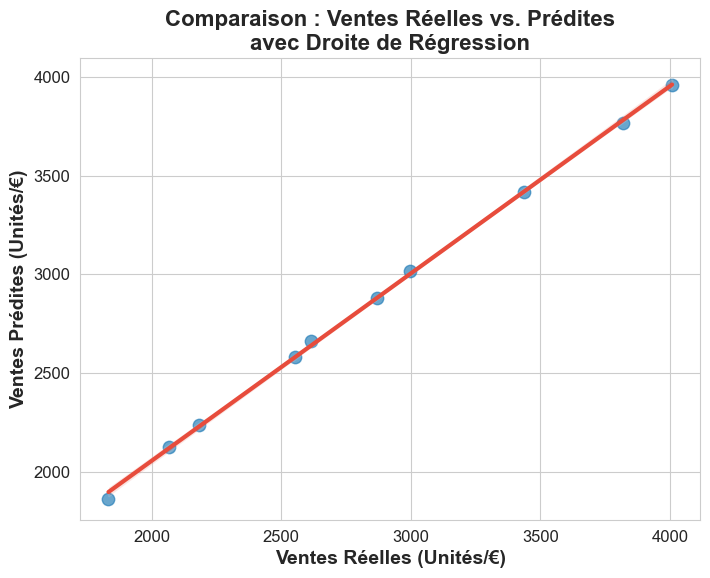

In [73]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# 1.Graphique de comparaison : Ventes Réelles vs Prédites
sns.regplot(x=y_test, y=y_pred, 
            scatter_kws={"s": 80, "color": "#2980b9", "alpha": 0.7},  # Style des points
            line_kws={"color": "#e74c3c", "lw": 3})  # Style de la droite

# sns.regplot(x=y_test, y=y_pred, scatter_kws={"s": 100, "color": "blue"}, 
#             line_kws={"color": "red"})

# --- 2. Ajout des labels et du titre ---
plt.xlabel("Ventes Réelles (Unités/€)", fontsize=14, fontweight='bold')
plt.ylabel("Ventes Prédites (Unités/€)", fontsize=14, fontweight='bold')
plt.title("Comparaison : Ventes Réelles vs. Prédites\navec Droite de Régression", fontsize=16, fontweight='bold')

# --- 3. Amélioration de la lisibilité ---
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- 4. Affichage du graphique ---
plt.show()

8. Prédiction sur de nouvelles données

In [83]:
new_data = pd.DataFrame({
    "Advertising_Budget": [1200],
    "Promotion_Spending": [430],
    "Competitor_Advertising": [500]
})

predicted_sales = model.predict(new_data)
print(f"Ventes prédites pour les nouvelles données : {predicted_sales[0]:.2f} €")

Ventes prédites pour les nouvelles données : 4188.63 €


### Conclusion:
Notre modèle est très performant. Il explique plus de 99 % des variations de ventes avec une marge d'erreur moyenne d'environ 30 unités. Pour un modèle de prédiction de ventes, c'est un résultat très solide.